## Ayudantía 19 Marzo 2026

### Taller de Herramientas Computacionales

### Listas comprimidas
$$\{ x^{2} \mid x \in \mathbb{N}, x \text{ es par y hasta 10} \}$$

In [24]:
# Sintaxis: [expresion for elemento in iterable if condicion]

cuadrados = [x**2 for x in range(11) if x % 2 == 0]

print(cuadrados)

[0, 4, 16, 36, 64, 100]


### Un pequeño recordatorio de las funciones

In [27]:
def f(x):
    y = x**2 + 7
    return y

print(f(3))

16


## Graficación

### Tipos de graficos 2D

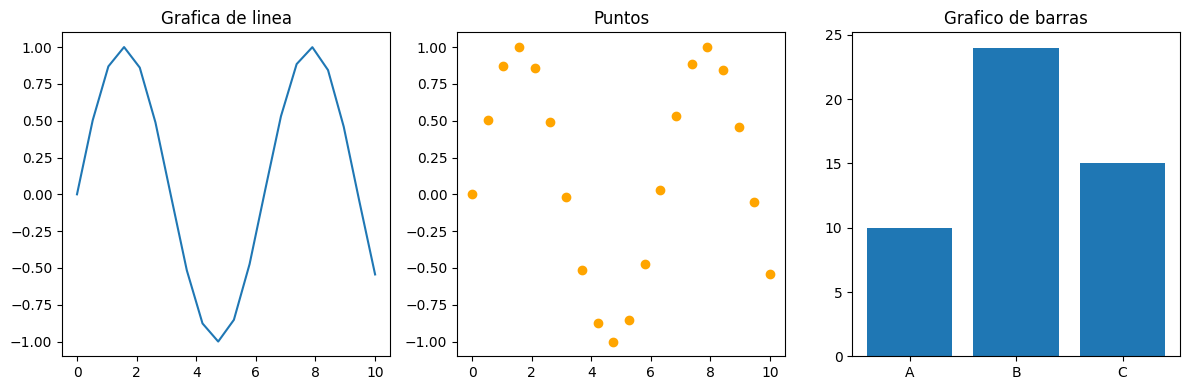

In [35]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 20)
y = np.sin(x)

fig, axs = plt.subplots(1,3, figsize=(12,4))

#Plot continuas
axs[0].plot(x,y, label='Seno')
axs[0].set_title('Grafica de linea')

# Scatter
axs[1].scatter(x,y,color='orange')
axs[1].set_title('Puntos')

# Barras:
axs[2].bar(['A','B','C'],[10,24,15])
axs[2].set_title('Grafico de barras')

plt.tight_layout()
plt.show()

### Tunning y personalización

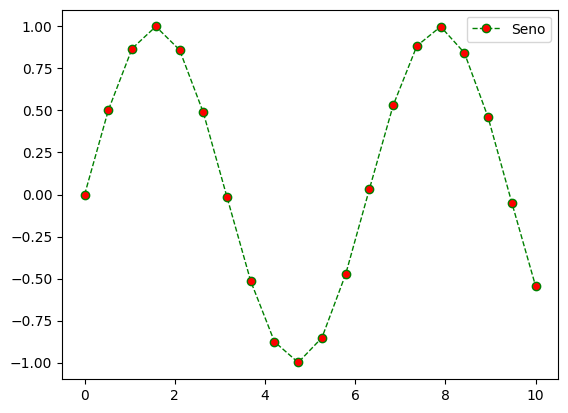

In [40]:
fig, ax = plt.subplots()

ax.plot(x,y,
        color = 'green',
        linestyle = '--',
        linewidth = 1,
        marker = 'o',
        markerfacecolor = 'red',
        label = 'Seno')

ax.set_title = ('Personalizado')
ax.set_xlabel = ('Tiempo')
ax.set_ylabel = ('Amplitud')

ax.legend(loc= 'upper right')
plt.show()

### Graficos 3D

$\sin(\sqrt{x^2 + y^2})$

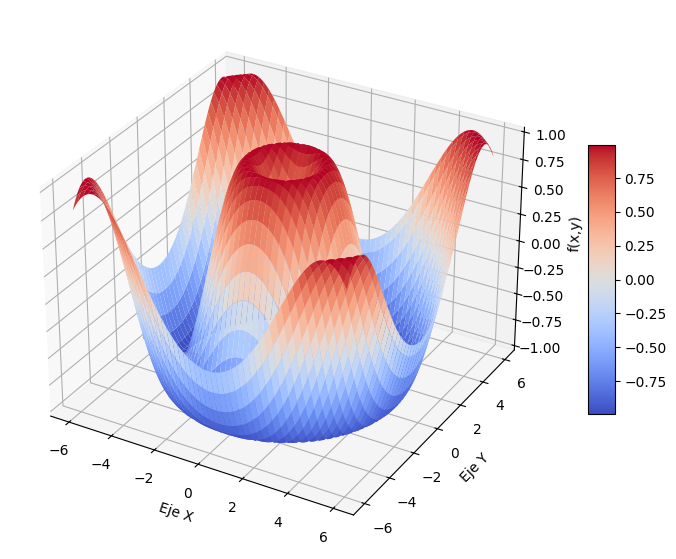

In [46]:
def g(x,y):
    r = np.sqrt(x**2 + y**2)
    return np.sin(r)

x = np.linspace(-6,6,100)
y = np.linspace(-6,6,100)
X, Y = np.meshgrid(x,y)
Z = g(X,Y)

fig = plt.figure(figsize=(10,7))
ax = plt.axes(projection = '3d')

surf = ax.plot_surface(X, Y , Z, cmap = 'coolwarm', edgecolor = 'none')

ax.set_title=('Grafica 3d')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('f(x,y)')

fig.colorbar(surf,shrink=0.5, aspect = 10)

plt.show()

### Graficas con varios datos/funciones y Grafico de graficos

In [ ]:
# Parabola de tarea

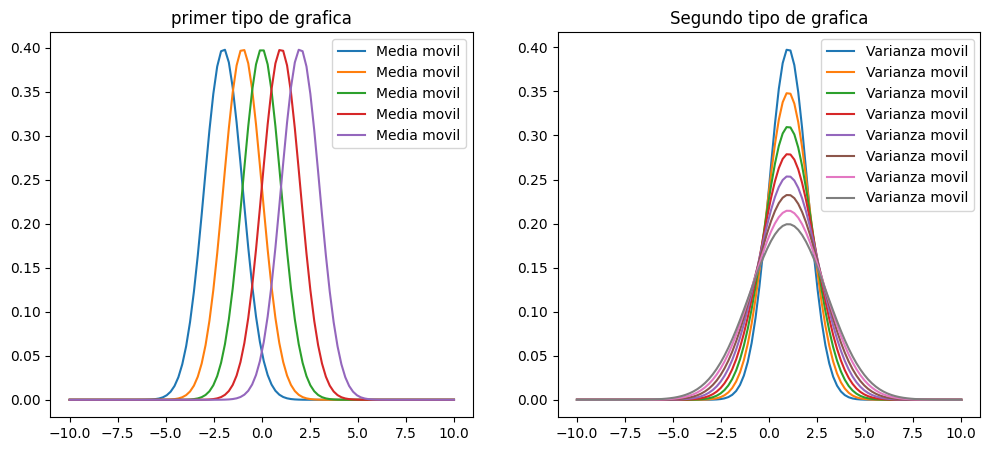

In [49]:
# Normal una donde vario sus medias y otra donde vario sus medias y sus varianzas

from scipy.stats import norm

x = np.linspace(-10,10,100)
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (12,5))

#Medias moviles
for m in np.linspace(-2,2,5):
    ax1.plot(x, norm.pdf(x,m,1), label = 'Media movil')
    ax1.set_title('primer tipo de grafica')
    ax1.legend()

#Varianza

for v in np.linspace(1,2,8):
    ax2.plot(x, norm.pdf(x,1,v), label = 'Varianza movil')
    ax2.set_title('Segundo tipo de grafica')
    ax2.legend()


plt.show()

In [ ]:
# 3D con grafica de varios parametros (Lorentz)

$ \begin{cases} 
\frac{dx}{dt} = \sigma(y - x) \\
\frac{dy}{dt} = x(\rho - z) - y \\
\frac{dz}{dt} = xy - \beta z 
\end{cases} $

### Intro APIS

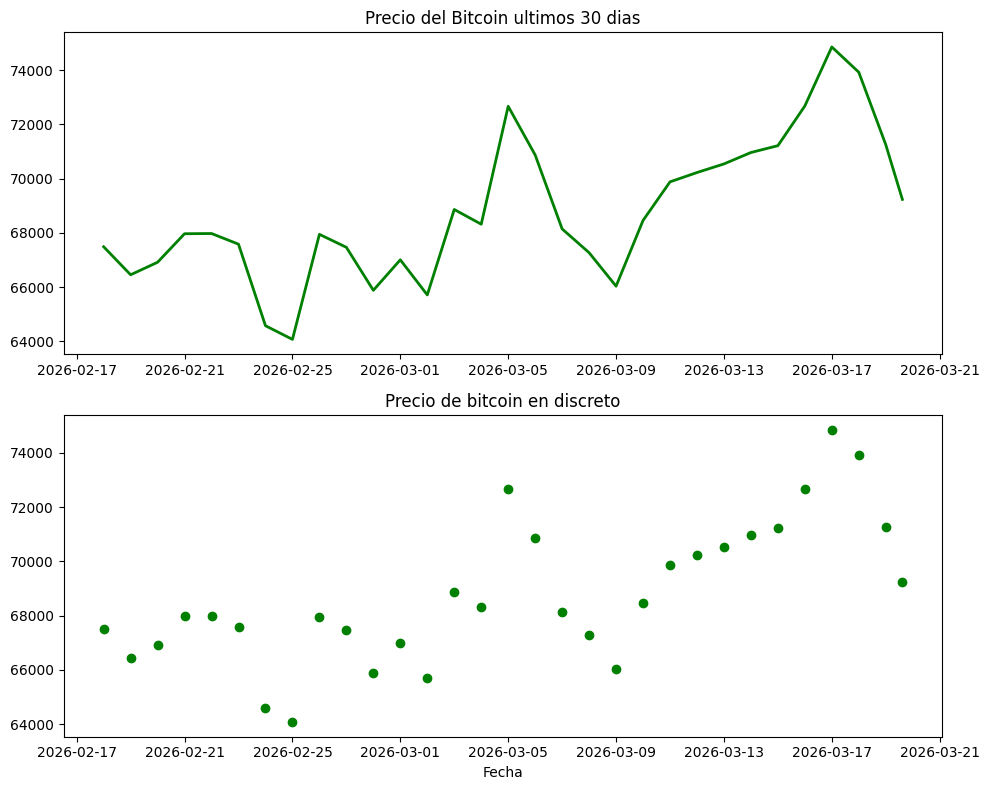

In [55]:
import requests
import pandas as pd

# Ploteo de bitcoin

url = 'https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=30&interval=daily'

data = requests.get(url).json()

# Extraer precios y tiempo
prices = [p[1] for p in data['prices']]
times = pd.to_datetime([p[0] for p in data['prices']], unit='ms')

fig, ax = plt.subplots(2,1,figsize = (10,8))

#Graficos de linea

ax[0].plot(times,prices,color='green',linewidth = 2)
ax[0].set_title('Precio del Bitcoin ultimos 30 dias')


# Dispersion

ax[1].scatter(times,prices, color='green')
ax[1].set_title('Precio de bitcoin en discreto')
ax[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()